# Possession-adjusted striker defensive work

## tl;dr

Across 69 central forwards with 1,200+ minutes in the 2015/16 Premier League and La Liga:

- After scaling defensive actions to 30 estimated opposition-possession minutes, the goals relationship weakens from **-0.17 to -0.11** in the Premier League and from **-0.23 to -0.16** in La Liga.
- The team-position relationship also weakens, especially in the Premier League (**+0.20 to +0.07**).
- Player rankings remain extremely stable across 10-, 15- and 20-second timing caps (**Spearman rho >= 0.998**).
- Team possession explains part of the original per-90 pattern, while tactical role and individual exceptions remain important.


## Context & Methods

### Research question

**After adjusting for time spent without the ball, is striker defensive involvement associated with goal output and final team position among central forwards with at least 1,200 minutes in the 2015/16 Premier League and La Liga?**

### Why this denominator

- **Not per 90:** playing time is not defensive opportunity; possession-dominant teams spend less time without the ball.
- **Not per 100 opposition possessions:** a five-second and a two-minute possession would count equally despite very different exposure.
- **Opposition-possession minutes:** duration is preserved, and scaling to 30 minutes compares every striker over the same estimated time available to defend.

StatsBomb provides event timestamps, possession IDs and possession teams rather than a continuous stopwatch. Consecutive live-event intervals are assigned to the recorded possession team and intersected with player on-pitch intervals. Dead-ball gaps are excluded and each interval is capped at 15 seconds. Ten- and twenty-second caps provide sensitivity checks.

The primary activity total contains pressures, duels, ball recoveries, interceptions and blocks. Counterpressures remain in the separate pressing index because they are a subset of pressures.

To reproduce the enriched data and figures:

```powershell
python scripts/analyze_striker_defensive_output.py
```


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "scripts" / "striker_defensive_output_analysis"
VISUALIZATION_DIR = PROJECT_ROOT / "visualizations"

players = pd.read_csv(OUTPUT_DIR / "striker_defensive_output_players.csv")
correlations = pd.read_csv(OUTPUT_DIR / "correlation_summary.csv")
standings = pd.read_csv(OUTPUT_DIR / "league_standings_2015_2016.csv")
sensitivity = pd.read_csv(OUTPUT_DIR / "timing_sensitivity_summary.csv")
timing_quality = pd.read_csv(OUTPUT_DIR / "possession_timing_quality.csv")

assert len(players) == 69
assert players["team_position"].notna().all()
assert players["estimated_oop_minutes"].gt(0).all()
assert standings.groupby("league")["played"].min().eq(38).all()
players.groupby("league").size().rename("players")

league
La Liga           33
Premier League    36
Name: players, dtype: int64

## Data

In [2]:
display_columns = [
    "league", "display_name", "team_name", "minutes", "estimated_oop_minutes",
    "goals", "goals_per90", "defensive_activity_per90",
    "defensive_activity_per30_oop", "team_position",
]
players[display_columns].sort_values(
    ["league", "goals_per90"], ascending=[True, False]
).groupby("league").head(8).round(2)

,league,display_name,team_name,minutes,estimated_oop_minutes,goals,goals_per90,defensive_activity_per90,defensive_activity_per30_oop,team_position
67,La Liga,Luis Suárez,Barcelona,3242.6,864.80,40,1.11,14.99,18.73,1
66,La Liga,Benzema,Real Madrid,2018.6,653.03,24,1.07,16.18,16.68,2
62,La Liga,Imanol Agirretxe Arruti,Real Sociedad,1203.9,409.33,13,0.97,21.01,20.59,9
59,La Liga,Kevin Gameiro,Sevilla,2161.8,758.43,16,0.67,22.15,21.04,7
43,La Liga,Griezmann,Atlético Madrid,3123.3,1213.53,22,0.63,30.54,26.20,3
65,La Liga,Aritz Aduriz Zubeldia,Athletic Club,2873.3,1063.32,20,0.63,19.36,17.44,5
47,La Liga,Borja González Tomás,Eibar,2652.5,1018.38,18,0.61,29.21,25.36,13
60,La Liga,Fernando José Torres Sanz,Atlético Madrid,1757.2,702.33,11,0.56,25.56,21.31,3
20,Premier League,Agüero,Manchester City,2422.8,811.03,24,0.89,18.13,18.05,4
21,Premier League,Vardy,Leicester City,3307.1,1386.68,24,0.65,23.76,18.89,1


## Results

In [3]:
relationships = [
    "Adjusted activity vs goals/90",
    "Adjusted activity vs position",
    "Per-90 activity vs goals/90",
    "Per-90 activity vs position",
]
correlations[
    (correlations["method"] == "spearman")
    & correlations["relationship"].isin(relationships)
][["sample", "n_players", "relationship", "coefficient", "p_value"]].round(3)

,sample,n_players,relationship,coefficient,p_value
0,La Liga,33,Adjusted activity vs goals/90,-0.159,0.377
6,La Liga,33,Adjusted activity vs position,0.263,0.139
12,La Liga,33,Per-90 activity vs goals/90,-0.232,0.193
14,La Liga,33,Per-90 activity vs position,0.326,0.064
16,Premier League,36,Adjusted activity vs goals/90,-0.106,0.537
22,Premier League,36,Adjusted activity vs position,0.072,0.676
28,Premier League,36,Per-90 activity vs goals/90,-0.171,0.320
30,Premier League,36,Per-90 activity vs position,0.204,0.232
32,Combined,69,Adjusted activity vs goals/90,-0.111,0.363
38,Combined,69,Adjusted activity vs position,0.164,0.178


In [4]:
sensitivity[[
    "sample", "gap_cap_seconds", "rank_correlation_with_primary",
    "goals_per90_rho", "team_position_rho",
]].round(3)

,sample,gap_cap_seconds,rank_correlation_with_primary,goals_per90_rho,team_position_rho
0,La Liga,10,0.998,-0.167,0.269
1,La Liga,15,1.000,-0.159,0.263
2,La Liga,20,1.000,-0.160,0.257
3,Premier League,10,0.999,-0.115,0.086
4,Premier League,15,1.000,-0.106,0.072
5,Premier League,20,1.000,-0.106,0.072
6,Combined,10,0.999,-0.114,0.166
7,Combined,15,1.000,-0.111,0.164
8,Combined,20,0.999,-0.110,0.163


In [5]:
timing_quality.groupby("league").agg(
    matches=("match_id", "count"),
    mean_clock_coverage=("clock_coverage_share", "mean"),
    minimum_clock_coverage=("clock_coverage_share", "min"),
    maximum_clock_coverage=("clock_coverage_share", "max"),
).round(3)

,matches,mean_clock_coverage,minimum_clock_coverage,maximum_clock_coverage
league,,,,
La Liga,380,0.736,0.617,0.851
Premier League,380,0.753,0.637,0.831


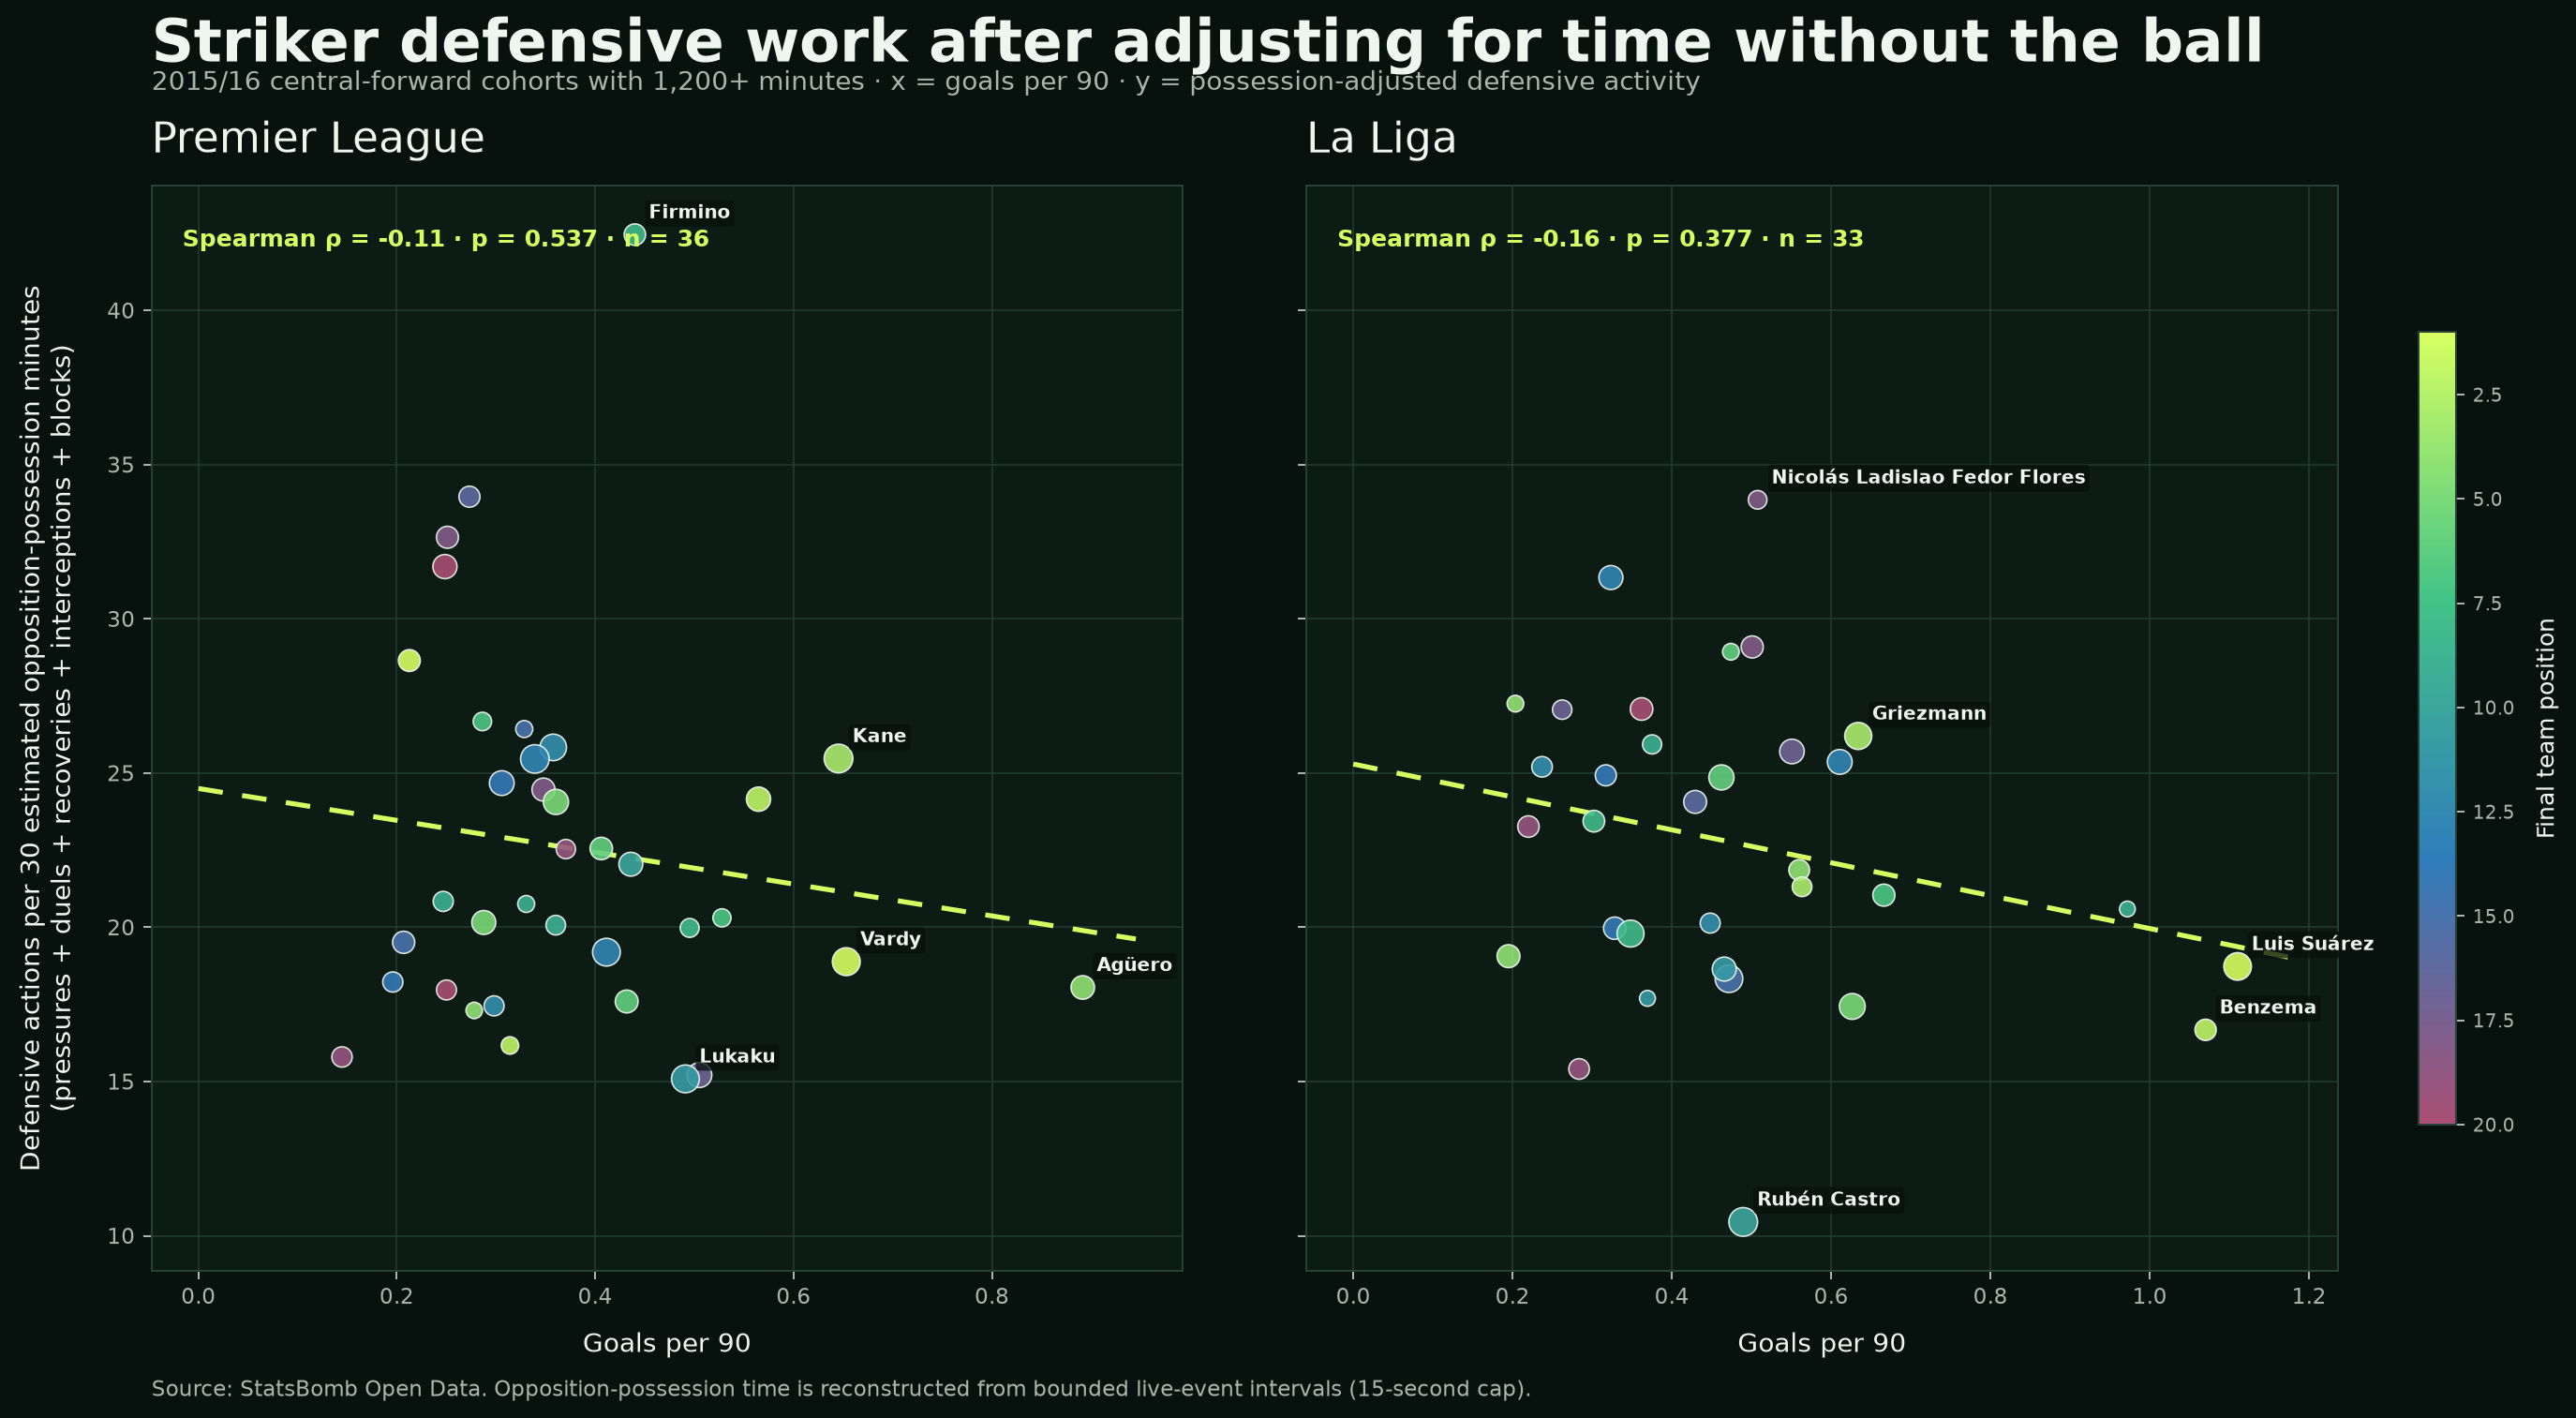

In [6]:
display(Image(
    filename=str(VISUALIZATION_DIR / "striker_defensive_output_relationships.png"),
    width=1200,
))

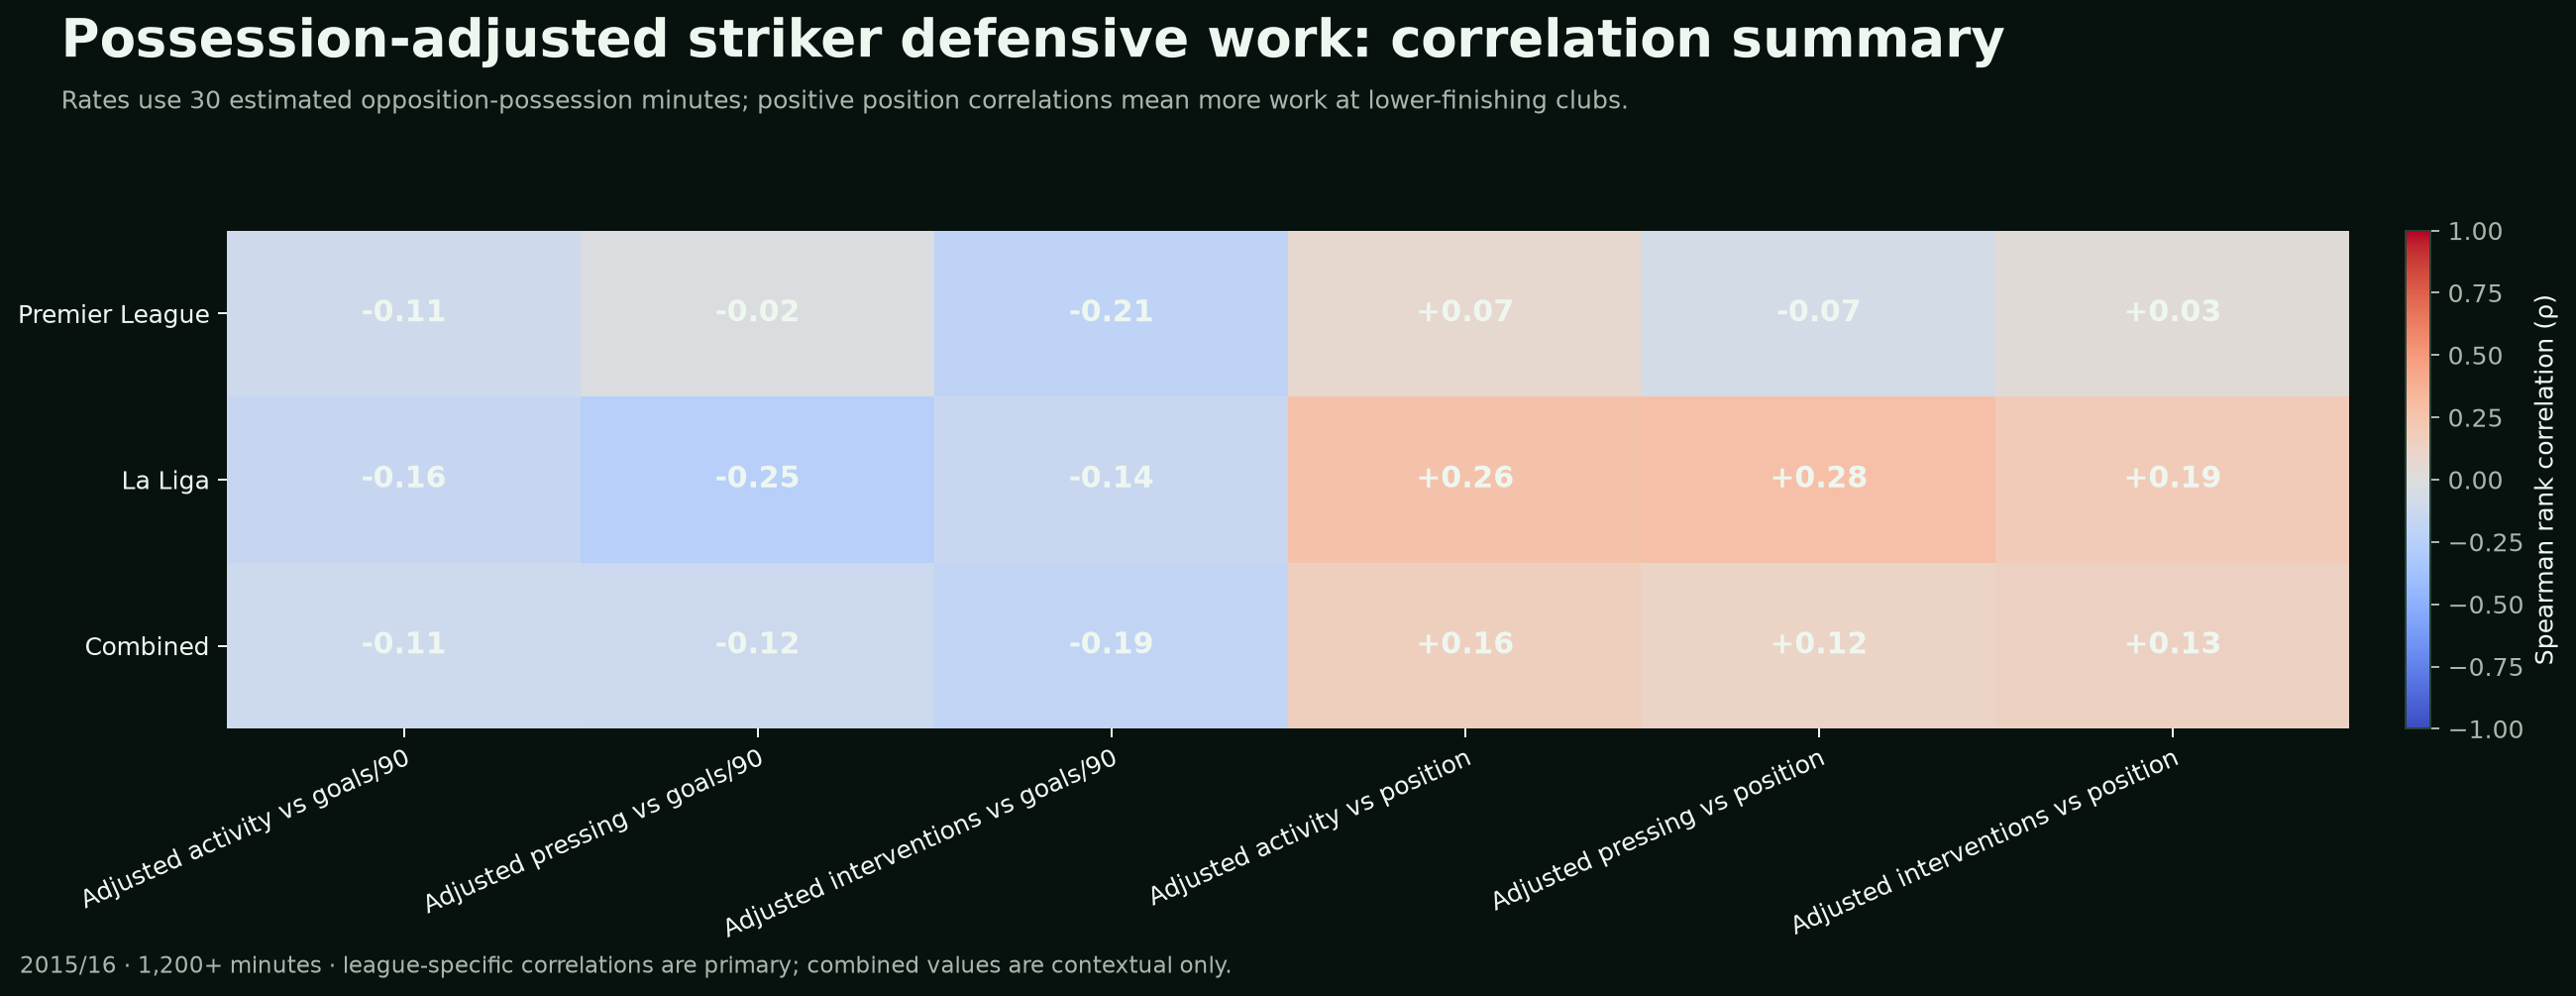

In [7]:
display(Image(
    filename=str(
        VISUALIZATION_DIR / "striker_defensive_output_correlation_heatmap.png"
    ),
    width=1200,
))

## Takeaways

1. The negative relationship between goal output and defensive activity remains, but is weaker after equalizing time without the ball.
2. The team-position relationship also declines, suggesting that stronger teams' greater possession contributed to the original per-90 pattern.
3. The timing assumption is not driving the player ordering: rankings are nearly identical under 10-, 15- and 20-second caps.
4. The metric improves opportunity fairness without claiming that every defensive minute is tactically identical. Field position, pressing scheme and opponent buildup style remain unmeasured.

### Next analytical step

Add opponent buildup passes and field position, then fit a multivariable model with club-aware uncertainty. This would distinguish time available to defend from the type and location of the defensive opportunities.
